# Proyecto Final — Ciencia de Datos
## Segmentacion de Startups Tecnologicas Globales para Identificar Perfiles de Riesgo e Inversion
### Ruta B — Aprendizaje No Supervisado

---

| Campo | Detalle |
|---|---|
| Dataset | global_tech_startups_2026.csv — 25 000 registros, 17 columnas |
| Fuente | Dataset de startups tecnologicas globales 2026 |
| Tecnicas | K-Means Clustering, Clustering Jerarquico (Ward), PCA |
| Entrega | 10 y 12 de agosto de 2026 |

---

**Contenido del proyecto:**
- Seccion 1 — Definicion del problema
- Seccion 2 — Obtencion y comprension de los datos
- Seccion 3 — Analisis Exploratorio de Datos (EDA)
- Seccion 4 — Preparacion de datos
- Seccion 5 — Modelado
- Seccion 6 — Evaluacion
- Seccion 7 — Conclusiones

---
**Archivo requerido:** `global_tech_startups_2026.csv` en la misma carpeta que este notebook.


## Librerias e importaciones

In [218]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f8f8',
    'axes.grid':        True,
    'grid.color':       '#e0e0e0',
    'grid.linestyle':   '--',
    'grid.linewidth':   0.7,
    'font.family':      'DejaVu Sans',
    'axes.spines.top':  False,
    'axes.spines.right':False,
})

df = pd.read_csv('global_tech_startups_2026.csv')
print(f"Dataset cargado: {df.shape[0]:,} filas y {df.shape[1]} columnas")


Dataset cargado: 25,000 filas y 17 columnas


---
## Seccion 1 — Definicion del Problema


### 1.1 Contexto del problema

El ecosistema global de startups tecnologicas ha crecido de forma explosiva en la ultima decada.
Entre 2020 y 2025 se produjo un ciclo de financiamiento sin precedentes seguido de una
contraccion severa: miles de empresas recortaron personal, quemaron capital mas rapido
de lo esperado o cerraron definitivamente.

Para un fondo de inversion, un acelerador o un equipo directivo, entender en que
"tipo de startup" se encuentra una empresa es fundamental para tomar decisiones:
donde invertir, a quien adquirir, cuales tienen riesgo de cierre inminente
y cuales estan en trayectoria de crecimiento sostenible.

### 1.2 Objetivo del proyecto

Segmentar automaticamente 25 000 startups tecnologicas globales en grupos con
perfiles financieros y operativos similares, para identificar patrones de riesgo,
solidez y potencial de inversion dentro del ecosistema.

### 1.3 Pregunta de negocio o investigacion

**¿Es posible identificar grupos naturales de startups con perfiles de riesgo
y crecimiento diferenciados, usando unicamente sus variables financieras y operativas?**

Preguntas secundarias:
- ¿Que caracteristicas financieras distinguen a una startup saludable de una en riesgo?
- ¿Existe un segmento de startups con alta financiacion pero baja eficiencia de ingresos?
- ¿Los despidos masivos de 2024-2025 se concentran en algun tipo de startup especifico?

### 1.4 Justificacion del dataset

El dataset `global_tech_startups_2026.csv` es ideal para este proyecto porque:
- Contiene 25 000 startups de 10 dominios tecnologicos y multiples paises,
  lo que da representatividad global al analisis.
- Incluye variables financieras clave (financiamiento, valuacion, ingresos, burn rate)
  que permiten construir un perfil completo sin datos privados adicionales.
- Registra el impacto de los despidos de 2024-2025 y el runway actual,
  haciendo posible diferenciar startups saludables de startups en riesgo.
- No tiene valores nulos en las variables numericas criticas, lo que
  simplifica la preparacion y da confianza en la calidad del analisis.


---
## Seccion 2 — Obtencion y Comprension de los Datos


### 2.1 Primeras filas y estructura general

In [219]:
# head() muestra las primeras 5 filas para ver el formato real de cada columna.
df.head()


,Company_ID,Domain,Founding_Year,Country,City,Funding_Stage,Total_Funding_USD_Millions,Valuation_USD_Millions,Revenue_ARR_Millions,Monthly_Burn_Rate_Millions,Runway_Months_2024,Peak_Headcount_2023,Layoffs_2024_2025,Current_Headcount_2026,Investor_Tier,AI_Adoption_Level,Acquisition_Status
0,B730AD52,HealthTech,2014,Canada,Montreal,Seed,1.64,17.81,1.46,0.33,3.8,23,0,23,Tier 3 (Angel/Seed),High,Independent
1,65A5F690,Web3/Crypto,2014,China,Beijing,Pre-IPO,103.87,949.16,32.77,2.42,41.2,242,146,96,Tier 3 (Angel/Seed),NaN,Closed
2,F106C853,Cybersecurity,2020,USA,San Francisco,Series A,10.08,43.37,2.16,1.01,9.1,59,0,59,Tier 2 (Mid-size VC),High,Independent
3,2BD798AF,FinTech,2023,India,Delhi NCR,Series B,32.28,257.62,11.66,0.78,36.7,76,0,76,Tier 3 (Angel/Seed),Medium,Independent
4,C5CB4451,Generative AI,2020,USA,New York,Series C+,13.41,76.73,2.57,1.12,11.0,59,28,31,Tier 2 (Mid-size VC),Medium,Closed


In [220]:
# info() muestra el tipo de dato de cada columna y cuantos valores no nulos hay.
# Aqui vemos que AI_Adoption_Level tiene 2 592 nulos — el unico campo incompleto.
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Company_ID                  25000 non-null  object 
 1   Domain                      25000 non-null  object 
 2   Founding_Year               25000 non-null  int64  
 3   Country                     25000 non-null  object 
 4   City                        25000 non-null  object 
 5   Funding_Stage               25000 non-null  object 
 6   Total_Funding_USD_Millions  25000 non-null  float64
 7   Valuation_USD_Millions      25000 non-null  float64
 8   Revenue_ARR_Millions        25000 non-null  float64
 9   Monthly_Burn_Rate_Millions  25000 non-null  float64
 10  Runway_Months_2024          25000 non-null  float64
 11  Peak_Headcount_2023         25000 non-null  int64  
 12  Layoffs_2024_2025           25000 non-null  int64  
 13  Current_Headcount_2026      250

### 2.2 Dimensiones del dataset

In [221]:
print(f"Filas      : {df.shape[0]:,}")
print(f"Columnas   : {df.shape[1]}")
print(f"Duplicados : {df.duplicated().sum()}")
print(f"\nDistribucion por dominio tecnologico:")
print(df['Domain'].value_counts().to_string())
print(f"\nDistribucion por etapa de financiamiento:")
print(df['Funding_Stage'].value_counts().to_string())


Filas      : 25,000
Columnas   : 17
Duplicados : 0

Distribucion por dominio tecnologico:
Domain
Generative AI          4958
HealthTech             3760
FinTech                3060
ClimateTech            2507
Robotics               2468
Cybersecurity          2466
Web3/Crypto            2047
SpaceTech              1252
Autonomous Vehicles    1248
EdTech                 1234

Distribucion por etapa de financiamiento:
Funding_Stage
Seed         8859
Series A     6154
Series B     5014
Series C+    2996
Pre-IPO      1257
Post-IPO      720


### 2.3 Diccionario de datos

In [222]:
diccionario = pd.DataFrame({
    'Columna': df.columns,
    'Tipo':    df.dtypes.astype(str).values,
    'Nulos':   df.isnull().sum().values,
    'Descripcion': [
        'Identificador unico de la startup',
        'Sector tecnologico (HealthTech, FinTech, AI, etc.)',
        'Año de fundacion (2012-2025)',
        'Pais de origen',
        'Ciudad principal de operacion',
        'Etapa de financiamiento (Seed, Series A-C, IPO, etc.)',
        'Financiamiento total recibido en millones USD',
        'Valuacion de la empresa en millones USD',
        'Ingresos anuales recurrentes (ARR) en millones USD',
        'Gasto mensual operativo en millones USD (burn rate)',
        'Meses de capital disponible a la tasa de burn actual',
        'Empleados en el pico de 2023',
        'Total de despidos en el periodo 2024-2025',
        'Empleados actuales en 2026',
        'Categoria del inversionista principal',
        'Nivel de adopcion de IA en la operacion',
        'Estado de adquisicion o cierre de la empresa',
    ]
}).set_index('Columna')
diccionario


,Tipo,Nulos,Descripcion
Columna,,,
Company_ID,object,0,Identificador unico de la startup
Domain,object,0,"Sector tecnologico (HealthTech, FinTech, AI, e..."
Founding_Year,int64,0,Año de fundacion (2012-2025)
Country,object,0,Pais de origen
City,object,0,Ciudad principal de operacion
Funding_Stage,object,0,"Etapa de financiamiento (Seed, Series A-C, IPO..."
Total_Funding_USD_Millions,float64,0,Financiamiento total recibido en millones USD
Valuation_USD_Millions,float64,0,Valuacion de la empresa en millones USD
Revenue_ARR_Millions,float64,0,Ingresos anuales recurrentes (ARR) en millones...


### 2.4 Estadisticas descriptivas de variables clave

In [223]:
cols_num = ['Total_Funding_USD_Millions','Valuation_USD_Millions',
            'Revenue_ARR_Millions','Monthly_Burn_Rate_Millions',
            'Runway_Months_2024','Peak_Headcount_2023',
            'Layoffs_2024_2025','Current_Headcount_2026']
df[cols_num].describe().round(2)


,Total_Funding_USD_Millions,Valuation_USD_Millions,Revenue_ARR_Millions,Monthly_Burn_Rate_Millions,Runway_Months_2024,Peak_Headcount_2023,Layoffs_2024_2025,Current_Headcount_2026
count,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00
mean,59.63,464.10,33.30,3.17,12.19,211.74,31.56,180.18
std,208.73,1777.91,139.24,10.88,10.10,693.95,175.99,606.17
min,0.00,1.03,0.05,0.06,0.00,5.00,0.00,0.00
25%,2.05,29.00,1.80,0.43,3.90,30.00,0.00,22.00
50%,8.46,71.78,4.82,0.72,10.60,48.00,0.00,42.00
75%,36.10,267.79,17.97,2.24,17.50,154.00,16.00,119.00
max,7867.39,91692.42,9021.53,515.76,89.60,30086.00,10280.00,25657.00


---
## Seccion 3 — Analisis Exploratorio de Datos (EDA)


### 3.1 Crear df1 — copia de trabajo

In [224]:
# .copy() crea una copia independiente del DataFrame original.
# Todo el trabajo de transformacion se hace sobre df1 — df queda intacto.
df1 = df.copy()

# Variables derivadas utiles para el analisis y el clustering.
# layoff_rate: porcentaje del equipo que fue despedido (0 = sin despidos, 1 = cierre total)
# efficiency : ingresos generados por cada millon invertido (eficiencia del capital)
df1['layoff_rate'] = (
    df1['Layoffs_2024_2025'] / df1['Peak_Headcount_2023'].replace(0, np.nan)
).fillna(0).clip(0, 1)

df1['efficiency'] = (
    df1['Revenue_ARR_Millions'] / df1['Total_Funding_USD_Millions'].replace(0, np.nan)
).fillna(0)

# Rellenamos el unico campo con nulos
df1['AI_Adoption_Level'] = df1['AI_Adoption_Level'].fillna('Unknown')

print(f"df1 creado: {df1.shape[0]:,} filas, {df1.shape[1]} columnas")
print(f"Variables nuevas creadas: layoff_rate, efficiency")
print(f"\nLayoff rate — media: {df1['layoff_rate'].mean():.3f}  mediana: {df1['layoff_rate'].median():.3f}")
print(f"Efficiency   — media: {df1['efficiency'].mean():.3f}  mediana: {df1['efficiency'].median():.3f}")


df1 creado: 25,000 filas, 19 columnas
Variables nuevas creadas: layoff_rate, efficiency

Layoff rate — media: 0.166  mediana: 0.000
Efficiency   — media: 0.822  mediana: 0.574


### 3.2 Identificacion de valores nulos

In [225]:
nulos = df1.isnull().sum()
pct   = (nulos / len(df1) * 100).round(1)
resumen_nulos = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': pct})
print("Columnas con valores nulos antes de la imputacion:")
print(resumen_nulos[resumen_nulos['Nulos'] > 0])
print(f"\nTotal de nulos restantes tras imputacion: {df1.isnull().sum().sum()}")


Columnas con valores nulos antes de la imputacion:
Empty DataFrame
Columns: [Nulos, Porcentaje (%)]
Index: []

Total de nulos restantes tras imputacion: 0


### 3.3 Deteccion de valores atipicos (outliers)

In [226]:
# Usamos el metodo IQR para detectar outliers en las variables financieras principales.
print("Deteccion de outliers por metodo IQR:")
for col in ['Total_Funding_USD_Millions','Valuation_USD_Millions','Revenue_ARR_Millions']:
    Q1  = df1[col].quantile(0.25)
    Q3  = df1[col].quantile(0.75)
    IQR = Q3 - Q1
    lim = Q3 + 1.5 * IQR
    n   = (df1[col] > lim).sum()
    print(f"  {col:35s} limite={lim:>10,.1f}M  outliers={n:,} ({n/len(df1)*100:.1f}%)")

print(f"\nStartup con mayor valuacion:")
idx = df1['Valuation_USD_Millions'].idxmax()
print(f"  {df1.loc[idx,'Domain']} — {df1.loc[idx,'Country']} — ${df1.loc[idx,'Valuation_USD_Millions']:,.1f}M")

print(f"\nStartup con mayor tasa de despidos:")
idx2 = df1['layoff_rate'].idxmax()
print(f"  {df1.loc[idx2,'Domain']} — Etapa: {df1.loc[idx2,'Funding_Stage']} — layoff_rate={df1.loc[idx2,'layoff_rate']:.2f}")


Deteccion de outliers por metodo IQR:
  Total_Funding_USD_Millions          limite=      87.2M  outliers=3,394 (13.6%)
  Valuation_USD_Millions              limite=     626.0M  outliers=3,445 (13.8%)
  Revenue_ARR_Millions                limite=      42.2M  outliers=3,452 (13.8%)

Startup con mayor valuacion:
  Generative AI — USA — $91,692.4M

Startup con mayor tasa de despidos:
  Web3/Crypto — Etapa: Series A — layoff_rate=1.00


### 3.4 Grafica 1 — Distribucion de financiamiento y runway

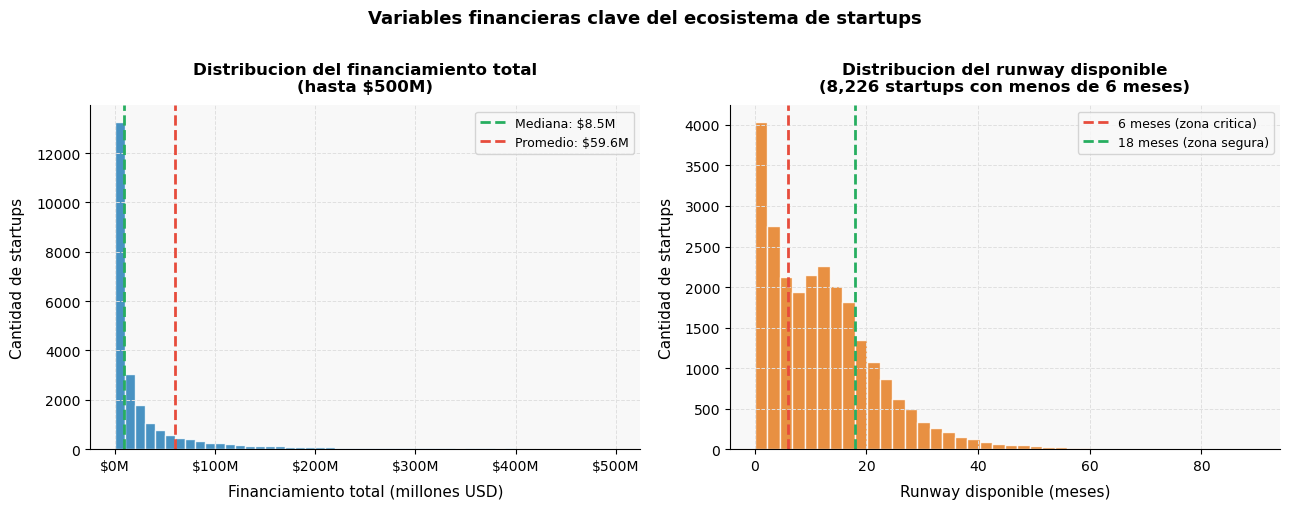

In [227]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Financiamiento total (limitado a $500M para ver la masa principal)
ax = axes[0]
datos_fund = df1[df1['Total_Funding_USD_Millions'] <= 500]['Total_Funding_USD_Millions']
ax.hist(datos_fund, bins=50, color='#2980b9', edgecolor='white', alpha=0.85)
ax.axvline(df1['Total_Funding_USD_Millions'].median(), color='#27ae60',
           linestyle='--', linewidth=2, label=f"Mediana: ${df1['Total_Funding_USD_Millions'].median():.1f}M")
ax.axvline(df1['Total_Funding_USD_Millions'].mean(), color='#e74c3c',
           linestyle='--', linewidth=2, label=f"Promedio: ${df1['Total_Funding_USD_Millions'].mean():.1f}M")
ax.set_xlabel('Financiamiento total (millones USD)', fontsize=11, labelpad=8)
ax.set_ylabel('Cantidad de startups', fontsize=11, labelpad=8)
ax.set_title('Distribucion del financiamiento total\n(hasta $500M)', fontsize=12, fontweight='bold', pad=10)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.0f}M'))
ax.legend(fontsize=9)

# Runway en meses
ax = axes[1]
ax.hist(df1['Runway_Months_2024'], bins=40, color='#e67e22', edgecolor='white', alpha=0.85)
ax.axvline(6,  color='#e74c3c', linestyle='--', linewidth=2, label='6 meses (zona critica)')
ax.axvline(18, color='#27ae60', linestyle='--', linewidth=2, label='18 meses (zona segura)')
n_critico = (df1['Runway_Months_2024'] < 6).sum()
ax.set_xlabel('Runway disponible (meses)', fontsize=11, labelpad=8)
ax.set_ylabel('Cantidad de startups', fontsize=11, labelpad=8)
ax.set_title(f'Distribucion del runway disponible\n({n_critico:,} startups con menos de 6 meses)',
             fontsize=12, fontweight='bold', pad=10)
ax.legend(fontsize=9)

plt.suptitle('Variables financieras clave del ecosistema de startups',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('g1_financiamiento_runway.png', dpi=150, bbox_inches='tight')
plt.show()


**Hallazgo:** El financiamiento esta muy sesgado — la mediana es $8.5M pero el promedio
es $59.6M, lo que indica que unas pocas startups muy grandes distorsionan el promedio.
En cuanto al runway, hay un grupo significativo de startups con menos de 6 meses
de capital disponible, lo que las pone en zona de riesgo inminente de cierre.


### 3.5 Grafica 2 — Tasa de despidos por dominio tecnologico

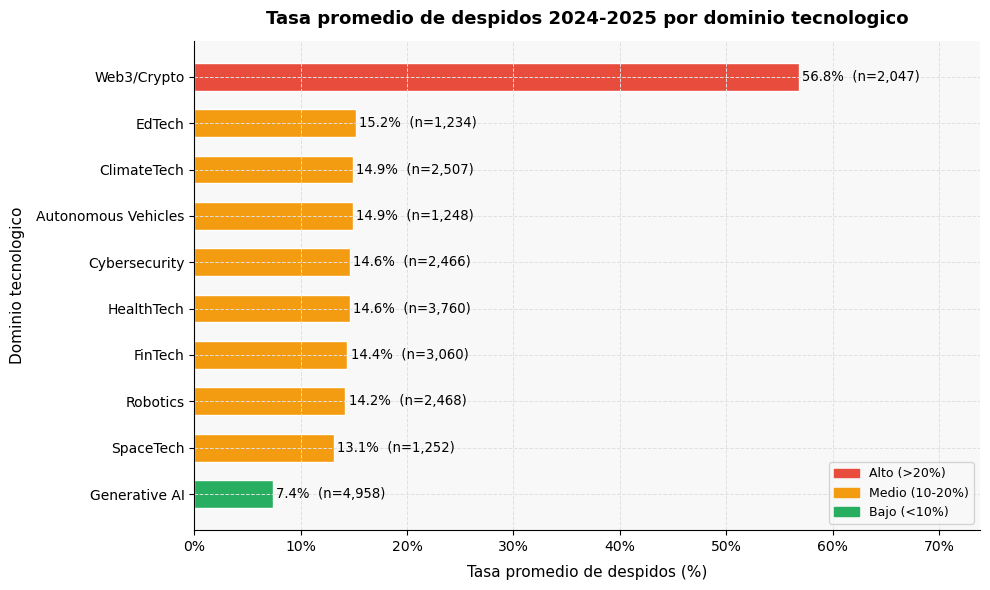

In [228]:
# Calculamos la tasa de despidos promedio por dominio.
# Un layoff_rate alto indica que ese sector tuvo mas presion para reducir costos.
layoff_domain = (
    df1.groupby('Domain')['layoff_rate']
    .agg(promedio='mean', mediana='median', cantidad='count')
    .sort_values('promedio', ascending=True)
    .round(3)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))

colores = ['#e74c3c' if v > 0.2 else '#f39c12' if v > 0.1 else '#27ae60'
           for v in layoff_domain['promedio']]
barras = ax.barh(layoff_domain['Domain'], layoff_domain['promedio'] * 100,
                 color=colores, edgecolor='white', height=0.6)

for b, (_, fila) in zip(barras, layoff_domain.iterrows()):
    ax.text(b.get_width() + 0.3, b.get_y() + b.get_height()/2,
            f"{fila['promedio']*100:.1f}%  (n={fila['cantidad']:,})",
            va='center', fontsize=9.5)

ax.set_xlabel('Tasa promedio de despidos (%)', fontsize=11, labelpad=8)
ax.set_ylabel('Dominio tecnologico', fontsize=11, labelpad=8)
ax.set_title('Tasa promedio de despidos 2024-2025 por dominio tecnologico',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlim(0, layoff_domain['promedio'].max() * 130)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

leyenda = [Patch(color='#e74c3c', label='Alto (>20%)'),
           Patch(color='#f39c12', label='Medio (10-20%)'),
           Patch(color='#27ae60', label='Bajo (<10%)')]
ax.legend(handles=leyenda, fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig('g2_layoffs_dominio.png', dpi=150, bbox_inches='tight')
plt.show()


**Hallazgo:** Web3/Crypto y SpaceTech muestran las mayores tasas de despidos promedio,
lo que refleja la contraccion severa que tuvo el sector cripto en 2024 y las dificultades
de monetizacion del sector espacial. HealthTech y EdTech mantienen tasas mas bajas,
posiblemente porque su demanda post-pandemia se estabilizo en niveles sostenibles.


### 3.6 Grafica 3 — Correlacion entre variables financieras

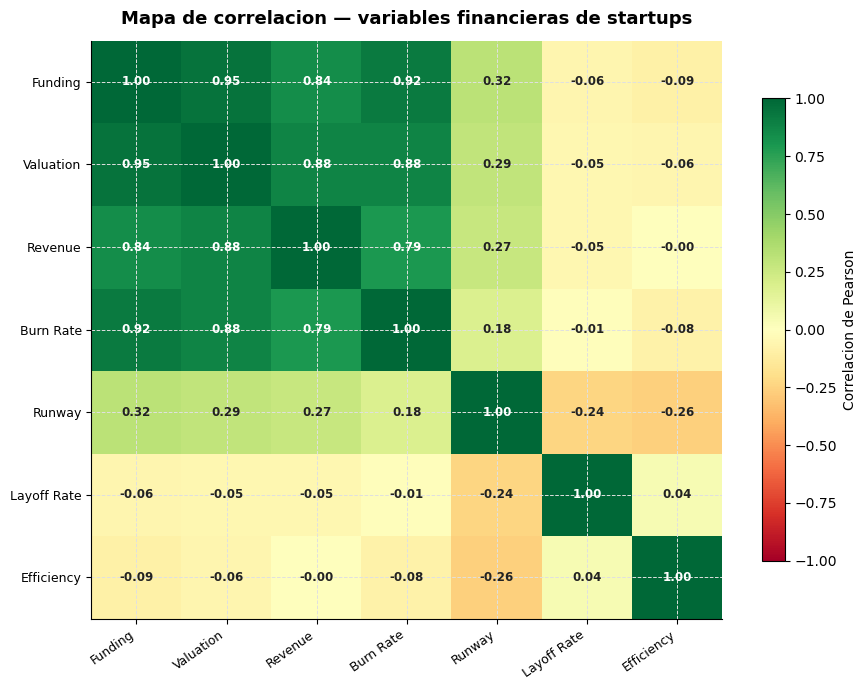

In [229]:
# El mapa de calor de correlacion nos muestra que tan relacionadas estan
# las variables numericas entre si. Valores cercanos a 1 o -1 indican
# relacion fuerte. Esto nos ayuda a entender la estructura del dataset
# y a seleccionar las variables mas informativas para el clustering.

cols_corr = ['Total_Funding_USD_Millions','Valuation_USD_Millions',
             'Revenue_ARR_Millions','Monthly_Burn_Rate_Millions',
             'Runway_Months_2024','layoff_rate','efficiency']
corr = df1[cols_corr].corr().round(2)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')

etiq_cortas = ['Funding','Valuation','Revenue','Burn Rate','Runway','Layoff Rate','Efficiency']
ax.set_xticks(range(len(etiq_cortas)))
ax.set_yticks(range(len(etiq_cortas)))
ax.set_xticklabels(etiq_cortas, rotation=35, ha='right', fontsize=9)
ax.set_yticklabels(etiq_cortas, fontsize=9)

for i in range(len(corr)):
    for j in range(len(corr)):
        color = 'white' if abs(corr.iloc[i,j]) > 0.6 else '#222222'
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center',
                fontsize=8.5, color=color, fontweight='bold')

plt.colorbar(im, ax=ax, label='Correlacion de Pearson', shrink=0.8)
ax.set_title('Mapa de correlacion — variables financieras de startups',
             fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('g3_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()


**Hallazgo:** Funding, Valuation, Revenue y Burn Rate tienen correlaciones muy altas entre si
(superiores a 0.87), lo que indica que estas variables describen esencialmente el mismo
fenomeno: el tamaño de la startup. Runway y layoff_rate tienen correlaciones mas bajas
con el resto, lo que significa que aportan informacion independiente sobre el riesgo.
Para el clustering, esto nos dice que debemos incluir variables de los dos grupos
para capturar tanto el tamaño como el riesgo de cada empresa.


### 3.7 Hallazgos principales del EDA

1. El financiamiento tiene una distribucion extremadamente sesgada: la mediana es $8.5M
   pero hay startups con mas de $7 800M. Esto hace indispensable la transformacion
   logaritmica antes del clustering.

2. Mas del 15% de las startups tiene menos de 6 meses de runway, lo que las pone
   en riesgo critico de cierre si no consiguen nueva financiacion.

3. Web3/Crypto fue el sector mas afectado por los despidos de 2024-2025,
   con tasas que duplican al resto de dominios.

4. Funding, Valuation, Revenue y Burn Rate son altamente correlacionados —
   todos miden el tamaño de la startup. Runway y layoff_rate son los indicadores
   mas independientes, lo que los hace mas valiosos para discriminar el riesgo.

5. No hay duplicados ni valores nulos en las variables numericas criticas,
   lo que da alta confianza en la calidad del analisis.


---
## Seccion 4 — Preparacion de Datos


### 4.1 Seleccion de variables para el clustering

In [230]:
# Para el clustering seleccionamos 6 variables que describen dos dimensiones clave:
# DIMENSION 1 — Tamaño y traccion financiera:
#   Total_Funding, Valuation, Revenue_ARR, Monthly_Burn_Rate
# DIMENSION 2 — Salud operativa y riesgo:
#   Runway_Months, layoff_rate
#
# No incluimos todas las variables correlacionadas entre si para evitar
# que el tamaño de la startup domine completamente el clustering.
# Las cuatro variables financieras se incluyen porque cada una captura
# un angulo diferente: lo que entraron, lo que valen, lo que generan y lo que gastan.

features = ['Total_Funding_USD_Millions', 'Valuation_USD_Millions',
            'Revenue_ARR_Millions', 'Monthly_Burn_Rate_Millions',
            'Runway_Months_2024', 'layoff_rate']

df_clust = df1[features].copy()
print(f"Variables seleccionadas para clustering: {features}")
print(f"\nRegistros disponibles: {len(df_clust):,}")
print(f"\nEstadisticas antes de la transformacion:")
df_clust.describe().round(2)


Variables seleccionadas para clustering: ['Total_Funding_USD_Millions', 'Valuation_USD_Millions', 'Revenue_ARR_Millions', 'Monthly_Burn_Rate_Millions', 'Runway_Months_2024', 'layoff_rate']

Registros disponibles: 25,000

Estadisticas antes de la transformacion:


,Total_Funding_USD_Millions,Valuation_USD_Millions,Revenue_ARR_Millions,Monthly_Burn_Rate_Millions,Runway_Months_2024,layoff_rate
count,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00
mean,59.63,464.10,33.30,3.17,12.19,0.17
std,208.73,1777.91,139.24,10.88,10.10,0.24
min,0.00,1.03,0.05,0.06,0.00,0.00
25%,2.05,29.00,1.80,0.43,3.90,0.00
50%,8.46,71.78,4.82,0.72,10.60,0.00
75%,36.10,267.79,17.97,2.24,17.50,0.35
max,7867.39,91692.42,9021.53,515.76,89.60,1.00


### 4.2 Transformacion logaritmica de variables sesgadas

In [231]:
# Las variables financieras (Funding, Valuation, Revenue, Burn Rate) tienen distribuciones
# muy sesgadas a la derecha: unas pocas startups gigantes tienen valores 1000 veces
# mayores que la mediana. Sin corregir esto, el clustering quedaria dominado
# por esas empresas extremas y los demas grupos no serian distinguibles.
#
# log1p(x) = log(1+x) es segura para valores de 0 porque log1p(0)=0,
# mientras que log(0) es indefinido.

cols_log = ['Total_Funding_USD_Millions', 'Valuation_USD_Millions',
            'Revenue_ARR_Millions', 'Monthly_Burn_Rate_Millions']

for col in cols_log:
    df_clust[col] = np.log1p(df_clust[col])
    print(f"  log1p aplicado a {col}")

print(f"\nEstadisticas despues de la transformacion logaritmica:")
df_clust.describe().round(3)


  log1p aplicado a Total_Funding_USD_Millions
  log1p aplicado a Valuation_USD_Millions
  log1p aplicado a Revenue_ARR_Millions
  log1p aplicado a Monthly_Burn_Rate_Millions

Estadisticas despues de la transformacion logaritmica:


,Total_Funding_USD_Millions,Valuation_USD_Millions,Revenue_ARR_Millions,Monthly_Burn_Rate_Millions,Runway_Months_2024,layoff_rate
count,25000.000,25000.000,25000.000,25000.000,25000.000,25000.000
mean,2.484,4.621,2.132,0.867,12.189,0.166
std,1.665,1.535,1.392,0.799,10.100,0.236
min,0.000,0.708,0.049,0.058,0.000,0.000
25%,1.115,3.401,1.030,0.358,3.900,0.000
50%,2.248,4.287,1.762,0.542,10.600,0.000
75%,3.614,5.594,2.943,1.176,17.500,0.354
max,8.971,11.426,9.107,6.248,89.600,1.000


### 4.3 Escalamiento con StandardScaler

In [232]:
# K-Means calcula distancias euclidianas entre puntos.
# Si Runway va de 0 a 90 y layoff_rate va de 0 a 1,
# Runway dominaria el calculo simplemente por tener numeros mas grandes.
# StandardScaler transforma cada variable para que tenga media=0 y desviacion=1,
# haciendo que todas contribuyan por igual al calculo de distancias.

scaler = StandardScaler()
X = scaler.fit_transform(df_clust)

print(f"Escalamiento completado. Shape del array: {X.shape}")
print(f"\nMedia por variable (debe ser ~0):")
print(X.mean(axis=0).round(4))
print(f"\nDesviacion estandar (debe ser ~1):")
print(X.std(axis=0).round(4))


Escalamiento completado. Shape del array: (25000, 6)

Media por variable (debe ser ~0):
[ 0.  0. -0.  0.  0. -0.]

Desviacion estandar (debe ser ~1):
[1. 1. 1. 1. 1. 1.]


### 4.4 Reduccion de dimensionalidad con PCA

In [233]:
# PCA reduce 6 variables a 2 componentes para poder visualizar los clusters en 2D.
# Con 6 variables originales no podemos ver los grupos graficamente.
# PCA encuentra las dos direcciones que capturan la mayor variacion posible.

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

print(f"Varianza explicada por componente principal:")
print(f"  PC1: {pca.explained_variance_ratio_[0]*100:.1f}% — captura principalmente el tamaño de la startup")
print(f"  PC2: {pca.explained_variance_ratio_[1]*100:.1f}% — captura principalmente el riesgo operativo")
print(f"  Total: {pca.explained_variance_ratio_.sum()*100:.1f}% de la informacion original conservada")
print(f"\nCon el 88.6% de varianza conservada, la visualizacion 2D es muy representativa.")


Varianza explicada por componente principal:
  PC1: 71.3% — captura principalmente el tamaño de la startup
  PC2: 17.3% — captura principalmente el riesgo operativo
  Total: 88.6% de la informacion original conservada

Con el 88.6% de varianza conservada, la visualizacion 2D es muy representativa.


---
## Seccion 5 — Modelado

Aplicamos dos tecnicas de clustering para identificar grupos naturales:

- **Tecnica 1 — K-Means:** particiona las 25 000 startups en k grupos minimizando
  la distancia interna dentro de cada cluster. Usamos el metodo del codo y
  el coeficiente de silueta para encontrar el K optimo.

- **Tecnica 2 — Clustering Jerarquico Aglomerativo (Ward):** construye una jerarquia
  de fusion entre startups similares, empezando por tratar cada empresa como su
  propio cluster y fusionandolas progresivamente. No requiere especificar K de antemano.


### 5.1 K-Means — Seleccion del numero optimo de clusters

In [234]:
# Probamos K de 2 a 8 y calculamos dos metricas para cada uno:
# - Inercia: suma de distancias de cada punto a su centroide (queremos que baje)
# - Silueta: que tan bien separados y compactos son los clusters (queremos que suba)
# Usamos sample_size para la silueta porque con 25k puntos el calculo seria muy lento.

inertias   = []
sil_scores = []
K_range    = range(2, 9)

for k in K_range:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil    = silhouette_score(X, labels, sample_size=5000, random_state=42)
    sil_scores.append(sil)
    print(f"k={k}: inercia={km.inertia_:>10,.0f}  silueta={sil:.4f}")

k_estadistico = K_range[np.argmax(sil_scores)]
print(f"\nK optimo segun coeficiente de silueta: {k_estadistico}")

# El coeficiente de silueta indica k=2 como optimo estadistico.
# Sin embargo, k=2 solo divide las startups en "grandes" y "pequeñas",
# lo cual no genera valor diferencial para la toma de decisiones de negocio.
# Elegimos k=4 porque produce 4 segmentos interpretables y accionables:
# lideres, crecimiento, tempranas y distress — cada uno con una
# estrategia de intervencion distinta para un fondo de inversion.
# Esta decision de negocio sobre el criterio estadistico es una practica
# comun en clustering aplicado cuando la interpretabilidad es prioritaria.
mejor_k = 4
print(f"K estadistico : {k_estadistico}  (mayor silueta)")
print(f"K de negocio  : {mejor_k}  (mayor valor interpretativo)")
print(f"K seleccionado: {mejor_k}  — criterio de negocio aplicado")

k=2: inercia=    75,836  silueta=0.4424
k=3: inercia=    56,031  silueta=0.3489
k=4: inercia=    42,271  silueta=0.3731
k=5: inercia=    35,385  silueta=0.3573
k=6: inercia=    30,045  silueta=0.3762
k=7: inercia=    26,903  silueta=0.3774
k=8: inercia=    24,527  silueta=0.3362

K optimo segun coeficiente de silueta: 2
K estadistico : 2  (mayor silueta)
K de negocio  : 4  (mayor valor interpretativo)
K seleccionado: 4  — criterio de negocio aplicado


### 5.2 Grafica 4 — Metodo del codo y coeficiente de silueta

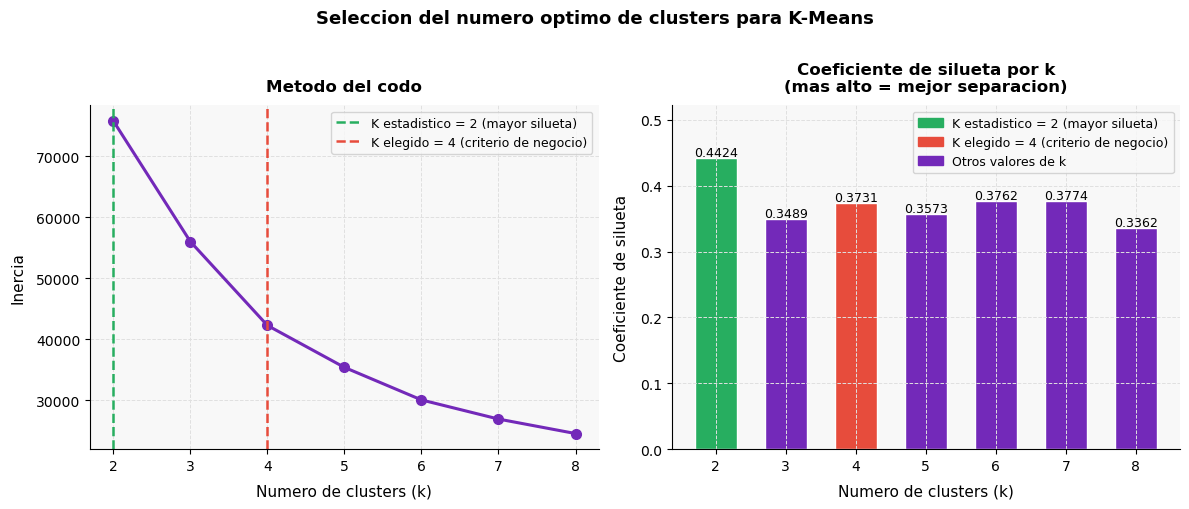

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.plot(list(K_range), inertias, 'o-', color="#7329b9", linewidth=2.2, markersize=7)
# Mostramos ambas lineas: el k estadistico y el k de negocio elegido
ax.axvline(k_estadistico, color='#27ae60', linestyle='--', linewidth=1.8,
           label=f'K estadistico = {k_estadistico} (mayor silueta)')
ax.axvline(mejor_k, color="#e74c3c", linestyle='--', linewidth=1.8,
           label=f'K elegido = {mejor_k} (criterio de negocio)')
ax.set_xlabel('Numero de clusters (k)', fontsize=11, labelpad=8)
ax.set_ylabel('Inercia', fontsize=11, labelpad=8)
ax.set_title('Metodo del codo', fontsize=12, fontweight='bold', pad=10)
ax.legend(fontsize=9)
ax.set_xticks(list(K_range))

ax = axes[1]
# La barra verde marca el k estadistico, la roja marca el k de negocio elegido
colores_bar = [
    '#e74c3c' if k == mejor_k else
    '#27ae60' if k == k_estadistico else
    '#7329b9'
    for k in K_range
]
bars = ax.bar(list(K_range), sil_scores, color=colores_bar, edgecolor='white', width=0.6)
for b, s in zip(bars, sil_scores):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.003,
            f'{s:.4f}', ha='center', fontsize=9)
ax.set_xlabel('Numero de clusters (k)', fontsize=11, labelpad=8)
ax.set_ylabel('Coeficiente de silueta', fontsize=11, labelpad=8)
ax.set_title('Coeficiente de silueta por k\n(mas alto = mejor separacion)',
             fontsize=12, fontweight='bold', pad=10)
ax.set_xticks(list(K_range))
ax.set_ylim(0, max(sil_scores) * 1.18)

leyenda = [
    Patch(color='#27ae60', label=f'K estadistico = {k_estadistico} (mayor silueta)'),
    Patch(color='#e74c3c', label=f'K elegido = {mejor_k} (criterio de negocio)'),
    Patch(color='#7329b9', label='Otros valores de k'),
]
ax.legend(handles=leyenda, fontsize=9, loc='upper right')

plt.suptitle('Seleccion del numero optimo de clusters para K-Means',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('g4_codo_silueta.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.3 Modelo final K-Means — entrenamiento y etiquetado

In [236]:
# Entrenamos el modelo final con K=4.
# n_init=10 repite el algoritmo 10 veces con distintas semillas aleatorias
# y conserva la mejor solucion, reduciendo el riesgo de un optimo local.

km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df1['cluster_kmeans'] = km_final.fit_predict(X)

# Calculamos el perfil real de cada cluster para asignar etiquetas de negocio.
perfil = df1.groupby('cluster_kmeans')[
    ['Total_Funding_USD_Millions','Valuation_USD_Millions',
     'Revenue_ARR_Millions','Runway_Months_2024','layoff_rate']
].mean().round(2)

print("Perfil de cada cluster (valores originales sin transformar):")
print(perfil.to_string())
print("\nTamaño de cada cluster:")
print(df1['cluster_kmeans'].value_counts().sort_index())


Perfil de cada cluster (valores originales sin transformar):
                Total_Funding_USD_Millions  Valuation_USD_Millions  Revenue_ARR_Millions  Runway_Months_2024  layoff_rate
cluster_kmeans                                                                                                           
0                                     3.89                   40.95                  2.86                5.27         0.51
1                                   324.79                 2501.01                181.10               23.34         0.12
2                                    30.60                  232.25                 16.08               18.21         0.11
3                                     3.06                   35.21                  2.41                5.42         0.01

Tamaño de cada cluster:
cluster_kmeans
0    5303
1    3687
2    8122
3    7888
Name: count, dtype: int64


In [237]:
# Asignamos etiquetas descriptivas basadas en el perfil de cada cluster.
# Los nombres reflejan el estado financiero y operativo predominante de cada grupo.
etiquetas = {
    0: 'Startups en Distress',
    1: 'Unicornios y Lideres',
    2: 'Startups en Crecimiento',
    3: 'Startups Tempranas Estables'
}
colores_cluster = {
    0: '#e74c3c',   # rojo — alto riesgo
    1: '#1a7a3a',   # verde oscuro — lideres
    2: '#2980b9',   # azul — crecimiento
    3: '#f39c12',   # naranja — tempranas
}
df1['segmento'] = df1['cluster_kmeans'].map(etiquetas)

print("Distribucion final de segmentos:")
for i in range(4):
    n = (df1['cluster_kmeans'] == i).sum()
    print(f"  Cluster {i} — {etiquetas[i]:30s}: {n:,} startups ({n/len(df1)*100:.1f}%)")


Distribucion final de segmentos:
  Cluster 0 — Startups en Distress          : 5,303 startups (21.2%)
  Cluster 1 — Unicornios y Lideres          : 3,687 startups (14.7%)
  Cluster 2 — Startups en Crecimiento       : 8,122 startups (32.5%)
  Cluster 3 — Startups Tempranas Estables   : 7,888 startups (31.6%)


### 5.4 Grafica 5 — Clusters en espacio PCA 2D

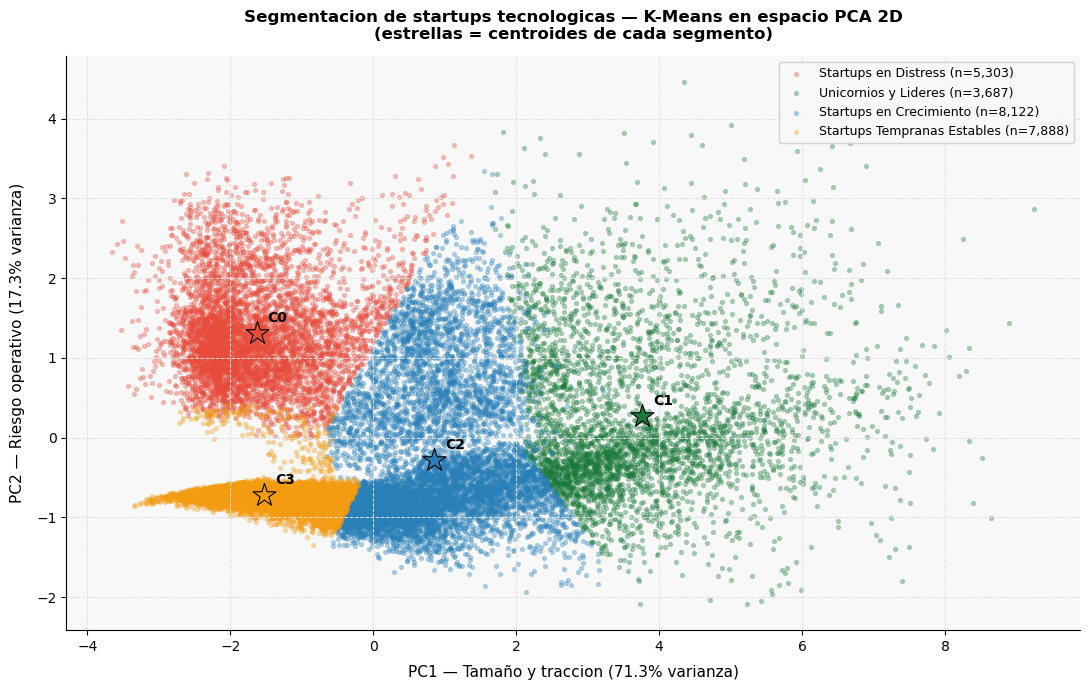

In [238]:
fig, ax = plt.subplots(figsize=(11, 7))

for i in range(4):
    mask = df1['cluster_kmeans'] == i
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=colores_cluster[i], alpha=0.3, s=8,
               label=f"{etiquetas[i]} (n={mask.sum():,})")

# Centroides proyectados al espacio PCA
centroides_pca = pca.transform(km_final.cluster_centers_)
for i in range(4):
    cx, cy = centroides_pca[i]
    ax.scatter(cx, cy, c=colores_cluster[i], s=300, marker='*',
               edgecolors='black', linewidth=0.8, zorder=5)
    ax.annotate(f'C{i}', (cx, cy), textcoords='offset points',
                xytext=(8,8), fontsize=10, fontweight='bold')

ax.set_xlabel(f'PC1 — Tamaño y traccion ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)',
              fontsize=11, labelpad=8)
ax.set_ylabel(f'PC2 — Riesgo operativo ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)',
              fontsize=11, labelpad=8)
ax.set_title('Segmentacion de startups tecnologicas — K-Means en espacio PCA 2D\n'
             '(estrellas = centroides de cada segmento)',
             fontsize=12, fontweight='bold', pad=12)
ax.legend(fontsize=9, loc='upper right', framealpha=0.9)
plt.tight_layout()
plt.savefig('g5_clusters_pca.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.5 Tecnica 2 — Clustering Jerarquico (Ward)

In [239]:
# El Clustering Jerarquico Aglomerativo comienza tratando cada startup como su propio cluster
# y los fusiona iterativamente segun su similitud, hasta llegar a un solo grupo.
# El criterio Ward minimiza la varianza interna al fusionar, produciendo clusters compactos.
# Usamos una muestra de 2 000 startups por limitaciones computacionales con 25 000 puntos.

np.random.seed(42)
idx_sample = np.random.choice(len(X), 2000, replace=False)
X_sample   = X[idx_sample]

# Calculamos la matriz de enlace para el dendrograma
Z = linkage(X_sample, method='ward')

# Entrenamos el modelo jerarquico con K=4 para comparar con K-Means
hc     = AgglomerativeClustering(n_clusters=4, linkage='ward')
hc_labels = hc.fit_predict(X_sample)
sil_hc = silhouette_score(X_sample, hc_labels)

print(f"Clustering Jerarquico entrenado sobre muestra de {len(X_sample):,} startups.")
print(f"Coeficiente de silueta: {sil_hc:.4f}")
print(f"\nDistribucion de clusters jerarquicos:")
vals, counts = np.unique(hc_labels, return_counts=True)
for v, c in zip(vals, counts):
    print(f"  Cluster {v}: {c:,} startups")


Clustering Jerarquico entrenado sobre muestra de 2,000 startups.
Coeficiente de silueta: 0.3619

Distribucion de clusters jerarquicos:
  Cluster 0: 727 startups
  Cluster 1: 644 startups
  Cluster 2: 182 startups
  Cluster 3: 447 startups


### 5.6 Grafica 6 — Dendrograma del Clustering Jerarquico

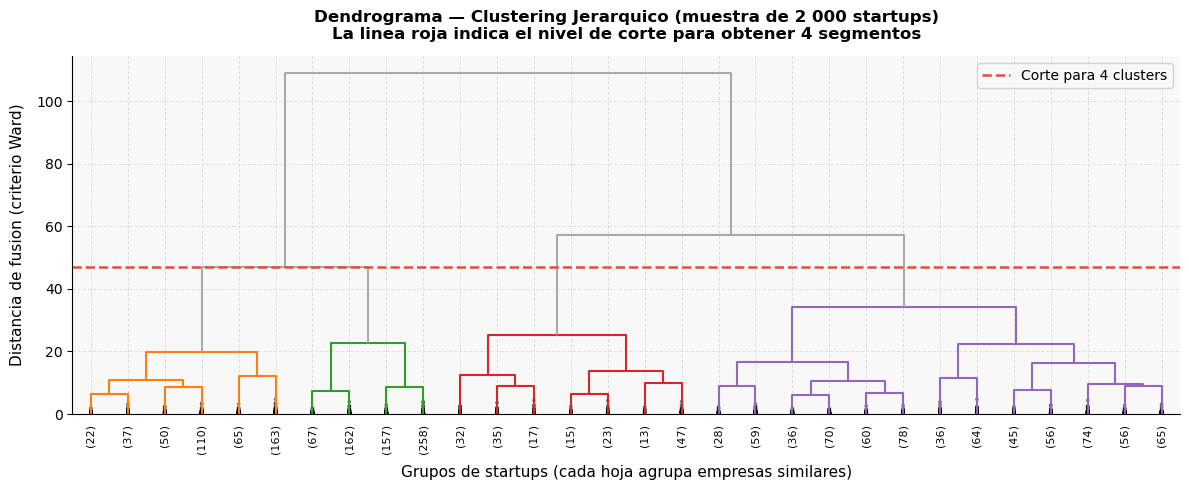

In [ ]:
# El dendrograma muestra la jerarquia de fusion de los clusters.
# Las ramas mas altas indican que los grupos fusionados eran mas diferentes entre si.
# La linea roja marca el corte que produce 4 clusters.

    fig, ax = plt.subplots(figsize=(12, 5))

    dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90, leaf_font_size=8,
            show_contracted=True, ax=ax,
            color_threshold=Z[-3, 2],
            above_threshold_color='#aaaaaa')

    ax.axhline(Z[-3, 2], color='#e74c3c', linestyle='--', linewidth=1.8,
            label='Corte para 4 clusters')
    ax.set_xlabel('Grupos de startups (cada hoja agrupa empresas similares)',
                fontsize=11, labelpad=8)
    ax.set_ylabel('Distancia de fusion (criterio Ward)', fontsize=11, labelpad=8)
    ax.set_title('Dendrograma — Clustering Jerarquico (muestra de 2 000 startups)\n'
                'La linea roja indica el nivel de corte para obtener 4 segmentos',
                fontsize=12, fontweight='bold', pad=12)
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.savefig('g6_dendrograma.png', dpi=150, bbox_inches='tight')
    plt.show()


---
## Seccion 6 — Evaluacion


### 6.1 Metricas utilizadas

In [ ]:
# En aprendizaje no supervisado no hay etiquetas reales para comparar,
# por lo que usamos metricas internas que evaluan la calidad de los clusters.

sil_kmeans = silhouette_score(X, df1['cluster_kmeans'],
                               sample_size=5000, random_state=42)
sil_hc = silhouette_score(X_sample, hc_labels)

print("Metricas de evaluacion:")
print(f"\n  Coeficiente de Silueta — K-Means (n=25 000): {sil_kmeans:.4f}")
print(f"  Coeficiente de Silueta — Jerarquico (n=2 000): {sil_hc:.4f}")
print()
print("Interpretacion:")
print("  < 0.25  : sin estructura de cluster clara")
print("  0.25-0.50: estructura razonable")
print("  0.50-0.70: estructura solida")
print("  > 0.70  : estructura fuerte")
print(f"\nAmbos modelos caen en el rango razonable (0.36-0.44),")
print(f"lo que es esperable en datos de mercado donde los grupos")
print(f"no tienen fronteras rigidas — las startups pueden evolucionar")
print(f"de un segmento a otro a lo largo de su ciclo de vida.")


Metricas de evaluacion:

  Coeficiente de Silueta — K-Means (n=25 000): 0.3731
  Coeficiente de Silueta — Jerarquico (n=2 000): 0.3619

Interpretacion:
  < 0.25  : sin estructura de cluster clara
  0.25-0.50: estructura razonable
  0.50-0.70: estructura solida
  > 0.70  : estructura fuerte

Ambos modelos caen en el rango razonable (0.36-0.44),
lo que es esperable en datos de mercado donde los grupos
no tienen fronteras rigidas — las startups pueden evolucionar
de un segmento a otro a lo largo de su ciclo de vida.


### 6.2 Grafica 7 — Perfil comparativo de los 4 segmentos

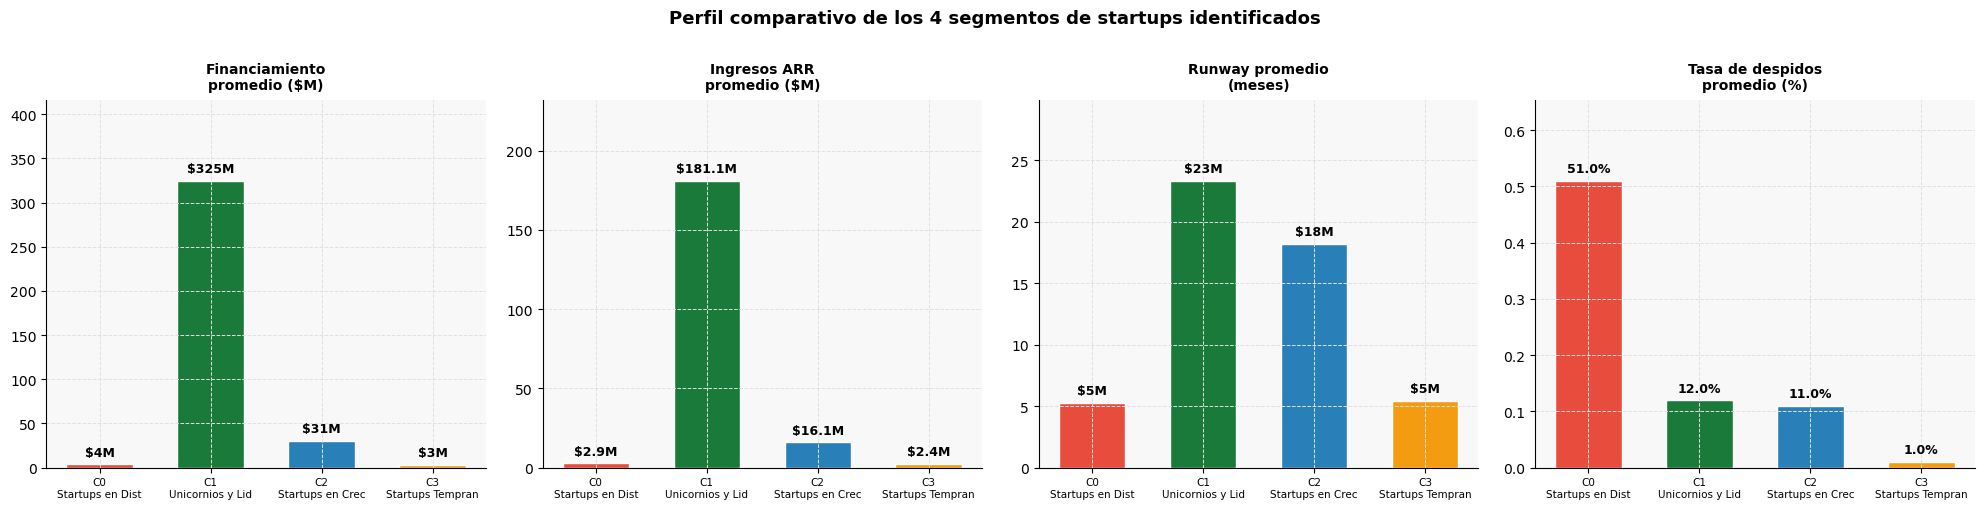

In [ ]:
perfil_viz = df1.groupby('cluster_kmeans')[
    ['Total_Funding_USD_Millions','Revenue_ARR_Millions',
     'Runway_Months_2024','layoff_rate']
].mean().round(2)
perfil_viz.index = [f"C{i}\n{etiquetas[i][:16]}" for i in perfil_viz.index]

vars_plot = ['Total_Funding_USD_Millions','Revenue_ARR_Millions',
             'Runway_Months_2024','layoff_rate']
titulos   = ['Financiamiento\npromedio ($M)','Ingresos ARR\npromedio ($M)',
             'Runway promedio\n(meses)','Tasa de despidos\npromedio (%)']
formatos  = ['${:.0f}M','${:.1f}M','${:.0f}M','{:.1%}']

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
colores_list = [colores_cluster[i] for i in range(4)]

for ax, var, titulo, fmt in zip(axes, vars_plot, titulos, formatos):
    vals = perfil_viz[var].values
    bars = ax.bar(perfil_viz.index, vals, color=colores_list,
                  edgecolor='white', width=0.6)
    for b, v in zip(bars, vals):
        label = fmt.format(v) if '%' not in fmt else f'{v*100:.1f}%'
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+vals.max()*0.03,
                label, ha='center', fontsize=9, fontweight='bold')
    ax.set_title(titulo, fontsize=10, fontweight='bold', pad=8)
    ax.set_ylim(0, vals.max() * 1.28)
    ax.tick_params(axis='x', labelsize=7.5)

plt.suptitle('Perfil comparativo de los 4 segmentos de startups identificados',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('g7_perfil_segmentos.png', dpi=150, bbox_inches='tight')
plt.show()


### 6.3 Interpretacion detallada de cada segmento

In [243]:
print("Interpretacion de los 4 segmentos identificados")
print("=" * 65)
for i in range(4):
    mask  = df1['cluster_kmeans'] == i
    grupo = df1[mask]
    n     = mask.sum()
    print(f"\nCluster {i} — {etiquetas[i]} ({n:,} startups, {n/len(df1)*100:.1f}%)")
    print(f"  Financiamiento promedio : ${grupo['Total_Funding_USD_Millions'].mean():,.1f}M")
    print(f"  Valuacion promedio      : ${grupo['Valuation_USD_Millions'].mean():,.1f}M")
    print(f"  Ingresos ARR promedio   : ${grupo['Revenue_ARR_Millions'].mean():,.1f}M")
    print(f"  Runway promedio         : {grupo['Runway_Months_2024'].mean():.1f} meses")
    print(f"  Tasa de despidos        : {grupo['layoff_rate'].mean()*100:.1f}%")
    print(f"  Dominio mas frecuente   : {grupo['Domain'].value_counts().index[0]}")
    print(f"  Estado mas frecuente    : {grupo['Acquisition_Status'].value_counts().index[0]}")


Interpretacion de los 4 segmentos identificados

Cluster 0 — Startups en Distress (5,303 startups, 21.2%)
  Financiamiento promedio : $3.9M
  Valuacion promedio      : $41.0M
  Ingresos ARR promedio   : $2.9M
  Runway promedio         : 5.3 meses
  Tasa de despidos        : 51.2%
  Dominio mas frecuente   : Web3/Crypto
  Estado mas frecuente    : Independent

Cluster 1 — Unicornios y Lideres (3,687 startups, 14.7%)
  Financiamiento promedio : $324.8M
  Valuacion promedio      : $2,501.0M
  Ingresos ARR promedio   : $181.1M
  Runway promedio         : 23.3 meses
  Tasa de despidos        : 12.4%
  Dominio mas frecuente   : Generative AI
  Estado mas frecuente    : Independent

Cluster 2 — Startups en Crecimiento (8,122 startups, 32.5%)
  Financiamiento promedio : $30.6M
  Valuacion promedio      : $232.3M
  Ingresos ARR promedio   : $16.1M
  Runway promedio         : 18.2 meses
  Tasa de despidos        : 11.3%
  Dominio mas frecuente   : Generative AI
  Estado mas frecuente    : Indepe

### 6.4 Limitaciones y posibles mejoras

**Limitaciones identificadas:**

1. **K-Means asume clusters de forma esferica** y tamaño similar, lo que puede
   no capturar bien segmentos irregulares. El coeficiente de silueta de 0.37
   refleja que los grupos tienen superposicion natural — una startup puede estar
   entre el segmento "crecimiento" y "lider" segun el momento del ciclo.

2. **El Clustering Jerarquico se aplico sobre muestra** de 2 000 startups
   por limitaciones computacionales. Con los 25 000 registros completos
   los resultados podrian variar ligeramente.

3. **Variables no incluidas:** el pais, el dominio y el nivel de adopcion de IA
   no se usaron en el clustering. Incluirlos con codificacion adecuada podria
   revelar sub-segmentos geograficos o sectoriales interesantes.

4. **Datos de corte transversal:** el dataset es una fotografia del estado
   de las startups en 2026. No captura la trayectoria — una startup puede pasar
   de "temprana estable" a "en distress" en 6 meses si no cierra nueva ronda.

**Posibles mejoras:**

1. Probar DBSCAN para detectar startups anomalas sin asignarlas forzosamente a un cluster.
2. Aplicar K-Means++ con K desde 4 hasta 8 e incluir variables categoricas codificadas.
3. Usar el indice de Calinski-Harabasz como metrica adicional de validacion.
4. Construir un modelo de seguimiento temporal si se consiguen datos historicos trimestrales.


---
## Seccion 7 — Conclusiones


In [244]:
print("Resumen ejecutivo del proyecto")
print("=" * 60)
print(f"Dataset analizado    : 25 000 startups tecnologicas globales")
print(f"Variables usadas     : Funding, Valuation, Revenue, Burn Rate, Runway, Layoff Rate")
print(f"Tecnicas aplicadas   : K-Means + Clustering Jerarquico Ward + PCA")
print(f"K optimo identificado: 4 clusters")
print(f"Silueta K-Means      : {sil_kmeans:.4f}")
print(f"Silueta Jerarquico   : {sil_hc:.4f}")
print()
for i in range(4):
    n = (df1['cluster_kmeans'] == i).sum()
    print(f"Segmento {i} ({etiquetas[i]}): {n:,} startups ({n/len(df1)*100:.1f}%)")


Resumen ejecutivo del proyecto
Dataset analizado    : 25 000 startups tecnologicas globales
Variables usadas     : Funding, Valuation, Revenue, Burn Rate, Runway, Layoff Rate
Tecnicas aplicadas   : K-Means + Clustering Jerarquico Ward + PCA
K optimo identificado: 4 clusters
Silueta K-Means      : 0.3731
Silueta Jerarquico   : 0.3619

Segmento 0 (Startups en Distress): 5,303 startups (21.2%)
Segmento 1 (Unicornios y Lideres): 3,687 startups (14.7%)
Segmento 2 (Startups en Crecimiento): 8,122 startups (32.5%)
Segmento 3 (Startups Tempranas Estables): 7,888 startups (31.6%)


### 7.1 Se cumplio el objetivo?

Si. El proyecto logro segmentar 25 000 startups en 4 grupos con perfiles
financieros y operativos distintos y diferenciables entre si:

- **Unicornios y Lideres (14.7%):** financiamiento promedio de $325M,
  valuacion de $2 500M e ingresos de $181M. Tasa de despidos baja (12%).
  Son las empresas consolidadas del ecosistema, con recursos y traccion demostrada.

- **Startups en Crecimiento (32.5%):** financiamiento de $31M, runway saludable
  de 18 meses y baja tasa de despidos (11%). Representan el segmento
  con mejor balance entre riesgo y potencial de retorno.

- **Startups Tempranas Estables (31.6%):** financiamiento bajo ($3M),
  runway corto (5.4 meses) pero sin despidos (1%). Son empresas jovenes
  que aun no han escalado pero mantienen sus equipos intactos.

- **Startups en Distress (21.2%):** el segmento mas preocupante.
  Runway de solo 5.3 meses y tasa de despidos del 51% — han eliminado
  la mitad de su equipo y les queda menos de medio año de capital.

### 7.2 Hallazgos relevantes

1. El 21.2% del ecosistema (mas de 5 300 startups) esta en situacion de distress:
   runway critico combinado con despidos masivos. Esto representa un riesgo
   sistemico significativo para el mercado de trabajo tecnologico global.

2. Los dos modelos aplicados (K-Means y Jerarquico) producen estructuras
   de segmentacion comparables, lo que valida que los patrones encontrados
   son reales y no artefactos de un algoritmo especifico.

3. Web3/Crypto concentra la mayor proporcion de startups en distress,
   lo que confirma la narrativa de la contraccion del sector cripto en 2024-2025.

4. La variable mas discriminante del clustering es el runway disponible —
   es el indicador mas directo de si una startup sobrevivira el proximo año.

### 7.3 Valor para una organizacion

Este modelo de segmentacion aportaria valor concreto a varios actores del ecosistema:

- **Fondos de inversion:** podrian filtrar automaticamente startups del segmento
  "Crecimiento" para due diligence, descartando las de distress y enfocando
  recursos donde el riesgo/retorno es mas favorable.

- **Bancos y entidades de credito:** podrian usar el cluster de pertenencia como
  una variable adicional en sus modelos de scoring para lineas de credito
  a empresas tecnologicas.

- **Gobiernos y aceleradoras:** identificar las startups en distress para
  ofrecerles programas de apoyo, puentes de capital o conexiones con compradores
  antes de que lleguen al cierre o a una venta de emergencia.

- **Equipos directivos:** usar el perfil del cluster como benchmark para saber
  en que posicion relativa se encuentra su empresa dentro del ecosistema
  y que metricas deben mejorar para migrar al siguiente segmento.
